<a href="https://colab.research.google.com/github/rahul-2005-tech/datascience/blob/main/project2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Attempting to download image from: https://raw.githubusercontent.com/opencv/opencv/master/samples/data/lena.jpg
Image downloaded successfully to /content/downloaded_image.jpg
ORIGINAL IMAGE DETAILS
Image Shape : (512, 512, 3)
Data Type   : uint8

GRAYSCALE IMAGE DETAILS
Grayscale Shape : (512, 512)


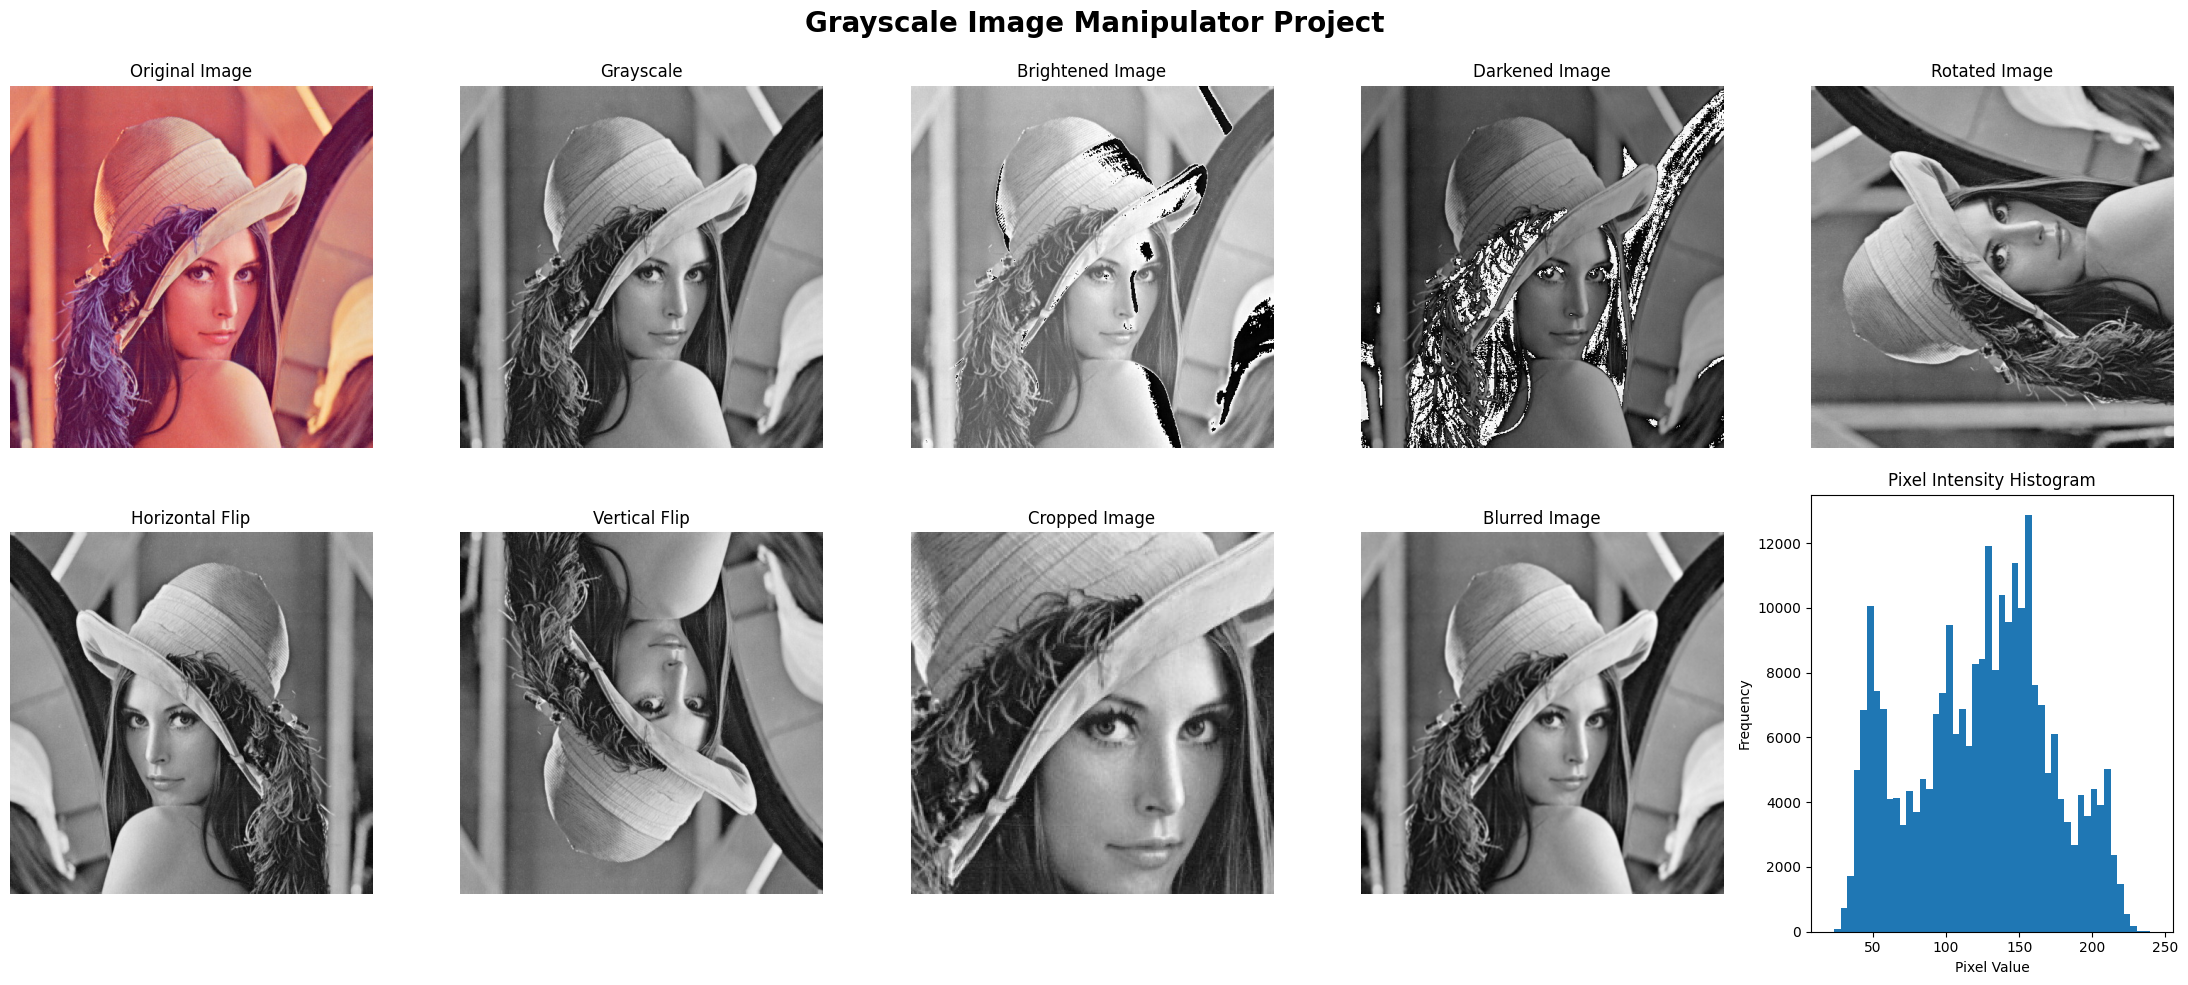


PROJECT COMPLETED SUCCESSFULLY


In [5]:
# GRAYSCALE IMAGE MANIPULATOR PROJECT

# Import Libraries
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import requests
import os # Import os for path handling

# STEP 1: LOAD IMAGE
# Replace with your image path or download one.

# Let's download a sample image to make the notebook runnable.
# Updated to a more reliable public image URL
image_url = "https://raw.githubusercontent.com/opencv/opencv/master/samples/data/lena.jpg"
image_filename = "downloaded_image.jpg"

# Define a directory to save the image
download_dir = "/content/"
if not os.path.exists(download_dir):
    os.makedirs(download_dir)
full_image_path = os.path.join(download_dir, image_filename)

try:
    print(f"Attempting to download image from: {image_url}")
    response = requests.get(image_url, stream=True)
    response.raise_for_status() # Raise an exception for HTTP errors
    with open(full_image_path, 'wb') as out_file:
        for chunk in response.iter_content(chunk_size=8192):
            out_file.write(chunk)
    image_path = full_image_path
    print(f"Image downloaded successfully to {image_path}")
except requests.exceptions.RequestException as e:
    print(f"Error downloading image: {e}")
    print("Please ensure you have an image file at the specified image_path or upload one.")
    # Fallback if download fails (e.g., use a pre-uploaded image or exit)
    # For demonstration, we'll try to proceed, but user might need to upload manually
    image_path = "/content/fallback_image.jpg" # Ensure this path exists if used as a fallback
    print(f"Using fallback image path: {image_path}")



# Load image
# Check if the image file actually exists before trying to read it
if os.path.exists(image_path):
    image = mpimg.imread(image_path)
else:
    # If the image still doesn't exist, create a placeholder or raise an error
    print(f"Error: Image file not found at {image_path}. Please upload an image or provide a valid path.")
    # Create a dummy image to prevent further errors for demonstration purposes
    image = np.zeros((100, 100, 3), dtype=np.uint8) # 100x100 black image

# STEP 2: HANDLE IMAGE DATA TYPE
# Some images load in range 0-1. Convert them to 0-255

if image.max() <= 1.0:
    image = image * 255

# Convert to unsigned integer
image = image.astype(np.uint8)

# STEP 3: DISPLAY IMAGE DETAILS

print("===================================")
print("ORIGINAL IMAGE DETAILS")
print("===================================")

print(f"Image Shape : {image.shape}")
print(f"Data Type   : {image.dtype}")

# STEP 4: CONVERT TO GRAYSCALE
# Weighted grayscale conversion
# Human eye sensitive:
# Green > Red > Blue

grayscale = np.dot(
    image[:, :, :3],
    [0.2989, 0.5870, 0.1140]
)

# Convert to uint8
grayscale = grayscale.astype(np.uint8)

print("\n===================================")
print("GRAYSCALE IMAGE DETAILS")
print("===================================")

print(f"Grayscale Shape : {grayscale.shape}")

# STEP 5: BRIGHTNESS MANIPULATION
# Increase brightness

bright_image = grayscale + 50

# Decrease brightness
dark_image = grayscale - 50

# Keep values between 0 and 255
bright_image = np.clip(bright_image, 0, 255)
dark_image = np.clip(dark_image, 0, 255)

# Convert back to uint8
bright_image = bright_image.astype(np.uint8)
dark_image = dark_image.astype(np.uint8)

# STEP 6: FLIP OPERATIONS
# Horizontal Flip
horizontal_flip = np.fliplr(grayscale)

# Vertical Flip
vertical_flip = np.flipud(grayscale)

# STEP 7: ROTATE IMAGE
# Rotate 90 degrees anticlockwise
rotated_image = np.rot90(grayscale)

# STEP 8: CROP IMAGE
height, width = grayscale.shape

# Crop center portion
cropped_image = grayscale[
    height // 4 : 3 * height // 4,
    width  // 4 : 3 * width  // 4
]

# STEP 9: BONUS CHALLENGE SIMPLE BLUR EFFECT

# Create copy
blurred_image = grayscale.copy()

# Apply averaging blur
for i in range(1, grayscale.shape[0] - 1):
    for j in range(1, grayscale.shape[1] - 1):
        # Average neighboring pixels
        blurred_image[i, j] = np.mean(
            grayscale[i-1:i+2, j-1:j+2]
        )

# Convert to uint8
blurred_image = blurred_image.astype(np.uint8)

# STEP 10: DISPLAY ALL IMAGES
fig, axes = plt.subplots(2, 5, figsize=(22, 10))

# Main Title
plt.suptitle(
    "Grayscale Image Manipulator Project",
    fontsize=20,
    fontweight="bold"
)

# ORIGINAL IMAGE
axes[0, 0].imshow(image)
axes[0, 0].set_title("Original Image")
axes[0, 0].axis("off")

# GRAYSCALE IMAGE
axes[0, 1].imshow(grayscale, cmap="gray")
axes[0, 1].set_title("Grayscale")
axes[0, 1].axis("off")

# BRIGHTENED IMAGE
axes[0, 2].imshow(bright_image, cmap="gray")
axes[0, 2].set_title("Brightened Image")
axes[0, 2].axis("off")

# DARKENED IMAGE
axes[0, 3].imshow(dark_image, cmap="gray")
axes[0, 3].set_title("Darkened Image")
axes[0, 3].axis("off")

# ROTATED IMAGE
axes[0, 4].imshow(rotated_image, cmap="gray")
axes[0, 4].set_title("Rotated Image")
axes[0, 4].axis("off")

# HORIZONTAL FLIP
axes[1, 0].imshow(horizontal_flip, cmap="gray")
axes[1, 0].set_title("Horizontal Flip")
axes[1, 0].axis("off")

# VERTICAL FLIP
axes[1, 1].imshow(vertical_flip, cmap="gray")
axes[1, 1].set_title("Vertical Flip")
axes[1, 1].axis("off")

# CROPPED IMAGE
axes[1, 2].imshow(cropped_image, cmap="gray")
axes[1, 2].set_title("Cropped Image")
axes[1, 2].axis("off")

# BLURRED IMAGE
axes[1, 3].imshow(blurred_image, cmap="gray")
axes[1, 3].set_title("Blurred Image")
axes[1, 3].axis("off")

# HISTOGRAM OF PIXEL VALUES
axes[1, 4].hist(
    grayscale.ravel(),
    bins=50
)

axes[1, 4].set_title("Pixel Intensity Histogram")
axes[1, 4].set_xlabel("Pixel Value")
axes[1, 4].set_ylabel("Frequency")

# FINAL DISPLAY SETTINGS
plt.tight_layout()
plt.show()

print("\n===================================")
print("PROJECT COMPLETED SUCCESSFULLY")
print("===================================")
